## **TELECOM CHURN PREDICTOR - DATA EXPLORATION**

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [33]:
df = pd.read_csv("C:/Users/chiboy/telecom_churn_project/data/raw/Telco-Customer-Churn.csv")

In [34]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [36]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### DATA CLEANING AND FEATURE ENGINEERING

In [37]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=["TotalCharges"])

In [38]:
df['AvgMonthlySpend'] = (df['TotalCharges'] / df['tenure']).round(2)

In [39]:
df['TenureGroup'] = pd.cut(df['tenure'], 
                           bins=[0, 12, 24, 48, 72], 
                           labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr'])
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,TenureGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.85,0-1yr
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,55.57,2-4yr
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,54.08,0-1yr
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.91,2-4yr
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,75.82,0-1yr


In [40]:
churn_rate = df['Churn'].value_counts(normalize=True)
print(churn_rate)

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64


### EXPLORATORY DATA ANLYSIS (EDA)

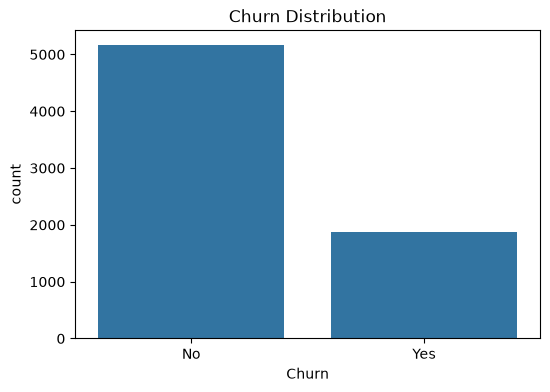

In [41]:
# 1. Target distribution plot
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.savefig("C:/Users/chiboy/telecom_churn_project/reports/churn_distribution.png")
plt.show()

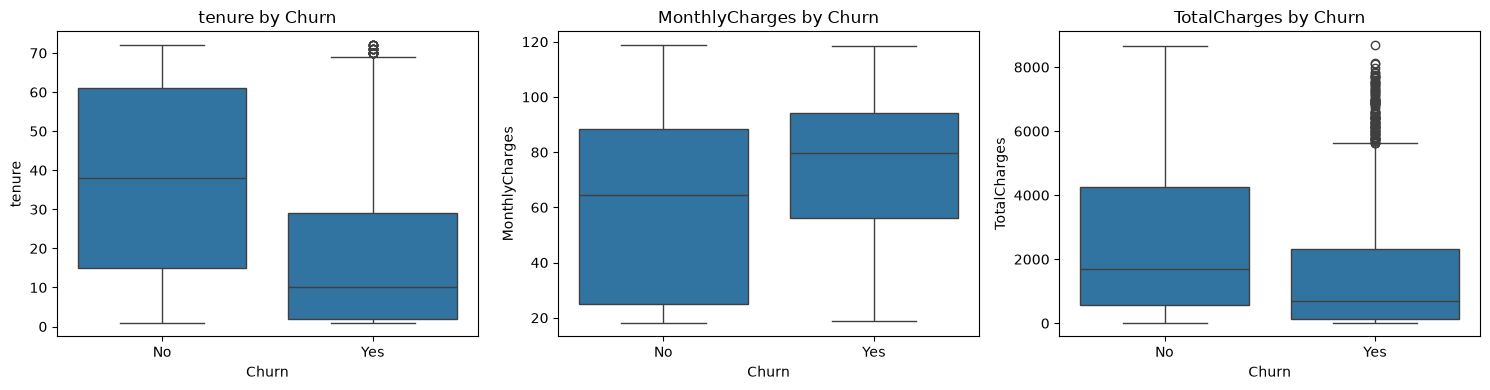

In [42]:
# 2. Numeric features distribution by churn
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(x='Churn', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} by Churn')
plt.tight_layout()
plt.savefig('C:/Users/chiboy/telecom_churn_project/reports/numeric_by_churn.png')
plt.show()

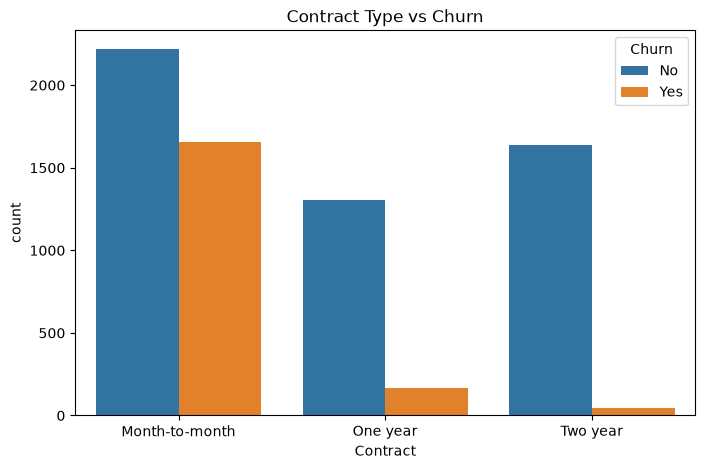

In [43]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Contract Type vs Churn')
plt.savefig('C:/Users/chiboy/telecom_churn_project/reports/contract_vs_churn.png')
plt.show()

In [44]:
#3. Encode categoricals first
df_encoded = df.copy()
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if col != 'customerID':
        df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

df_encoded['TenureGroup'] = LabelEncoder().fit_transform(df_encoded['TenureGroup'])
df_encoded_no_id = df_encoded.drop('customerID', axis=1)

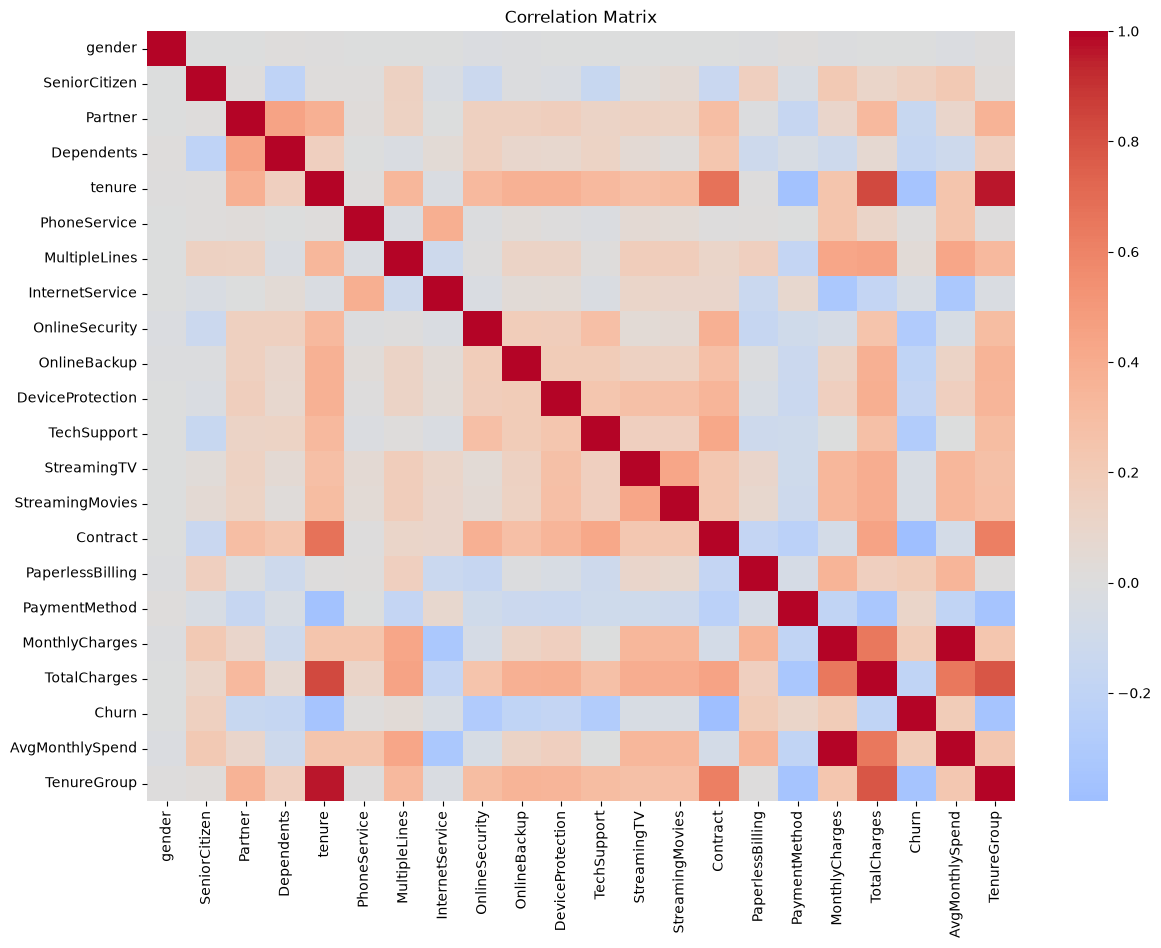

In [45]:
# 4. Correlation heatmap
plt.figure(figsize=(14,10))
corr = df_encoded_no_id.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.savefig('C:/Users/chiboy/telecom_churn_project/reports/correlation_matrix.png')
plt.show()

In [46]:
# Get top correlations with Churn
top_churn_features = corr['Churn'].sort_values(ascending=False)

print("Features that INCREASE churn (positive correlation):")
print(top_churn_features.head(10))

print("\nFeatures that DECREASE churn (negative correlation):")
print(top_churn_features.tail(10))

Features that INCREASE churn (positive correlation):
Churn               1.000000
MonthlyCharges      0.192858
AvgMonthlySpend     0.192032
PaperlessBilling    0.191454
SeniorCitizen       0.150541
PaymentMethod       0.107852
MultipleLines       0.038043
PhoneService        0.011691
gender             -0.008545
StreamingTV        -0.036303
Name: Churn, dtype: float64

Features that DECREASE churn (negative correlation):
Partner            -0.149982
Dependents         -0.163128
DeviceProtection   -0.177883
OnlineBackup       -0.195290
TotalCharges       -0.199484
TechSupport        -0.282232
OnlineSecurity     -0.289050
TenureGroup        -0.347133
tenure             -0.354049
Contract           -0.396150
Name: Churn, dtype: float64


In [47]:
df.to_csv('C:/Users/chiboy/telecom_churn_project/data/processed/telecom_churn_cleaned.csv', index=False)